# Epochs — Exploratory Data Analysis

Analyze class balance, splits, artists, missing values, and leakage-oriented patterns.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"
df = pd.read_csv(DATA_DIR / "fma_track_metadata.csv")

print("Shape:", df.shape)
print("\nMissing values:\n", df.isna().sum())
print("\nDuplicate track IDs:", df["track_id"].duplicated().sum())
print("Unique artists:", df["artist_id"].nunique())
print("Unique genres:", df["genre"].nunique())


Shape: (8000, 6)

Missing values:
 track_id        0
split           0
genre           0
artist_id       0
audio_path      0
audio_exists    0
dtype: int64

Duplicate track IDs: 0
Unique artists: 2309
Unique genres: 8


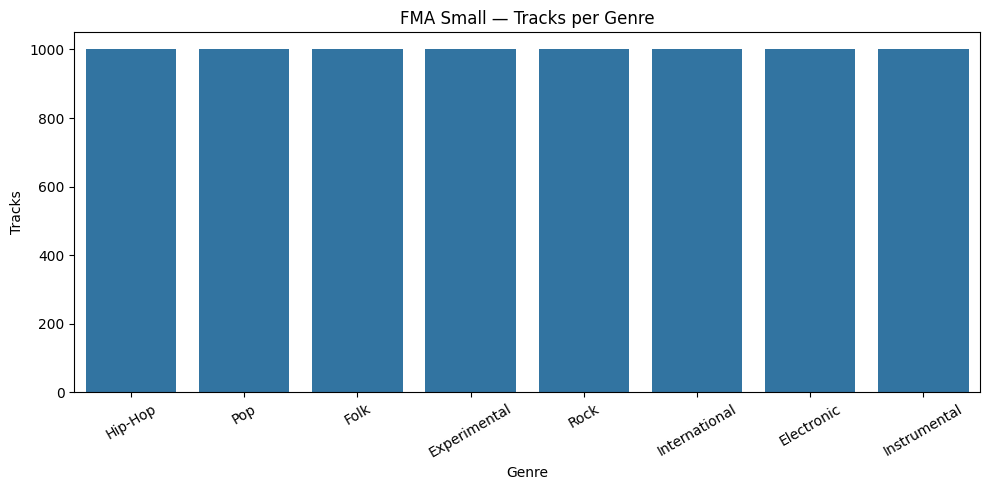

In [2]:
genre_counts = df["genre"].value_counts().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=genre_counts.index, y=genre_counts.values)
plt.title("FMA Small — Tracks per Genre")
plt.xlabel("Genre"); plt.ylabel("Tracks")
plt.xticks(rotation=30); plt.tight_layout(); plt.show()


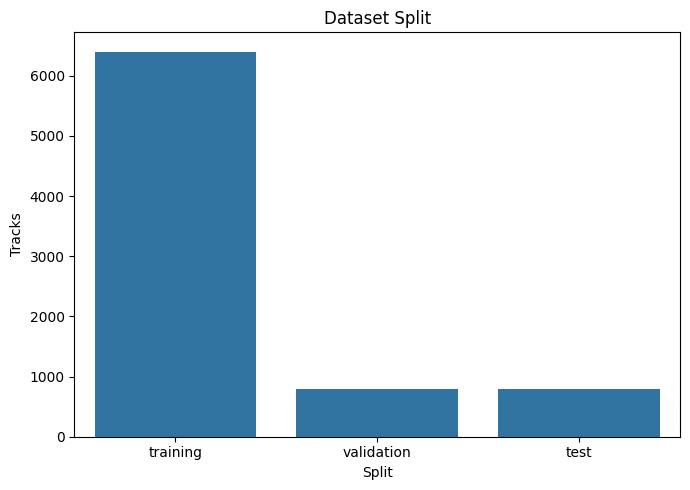

In [3]:
split_counts = df["split"].value_counts()
plt.figure(figsize=(7,5))
sns.barplot(x=split_counts.index, y=split_counts.values)
plt.title("Dataset Split")
plt.xlabel("Split"); plt.ylabel("Tracks")
plt.tight_layout(); plt.show()


In [4]:
artist_counts = df.groupby("artist_id")["track_id"].count()
print(artist_counts.describe())
print("\nTracks from artists with multiple tracks:",
      int(artist_counts[artist_counts > 1].sum()))


count    2309.000000
mean        3.464703
std         6.831355
min         1.000000
25%         1.000000
50%         1.000000
75%         4.000000
max       208.000000
Name: track_id, dtype: float64

Tracks from artists with multiple tracks: 6802


split          test  training  validation
genre                                    
Electronic      100       800         100
Experimental    100       800         100
Folk            100       800         100
Hip-Hop         100       800         100
Instrumental    100       800         100
International   100       800         100
Pop             100       800         100
Rock            100       800         100


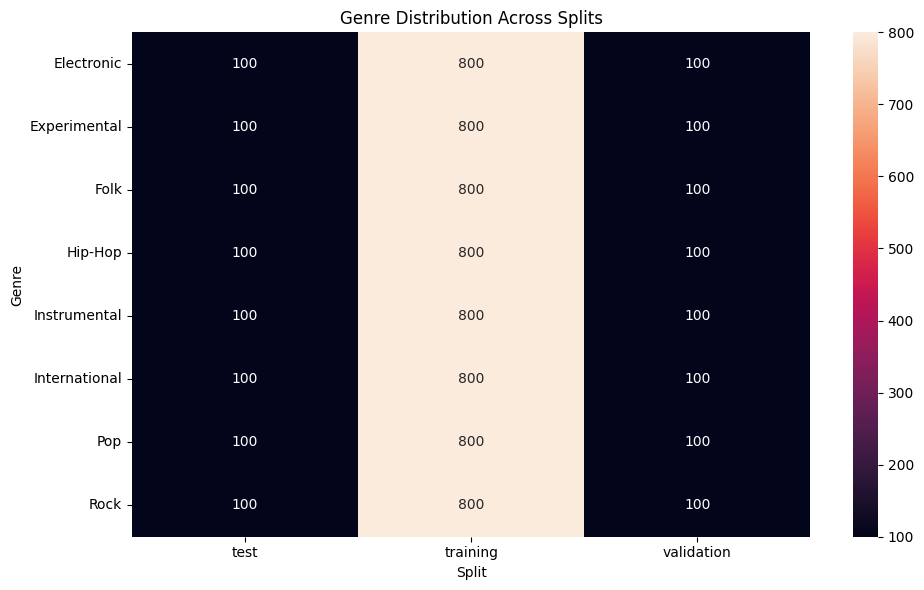

In [5]:
genre_split = pd.crosstab(df["genre"], df["split"])
print(genre_split)

plt.figure(figsize=(10,6))
sns.heatmap(genre_split, annot=True, fmt="d")
plt.title("Genre Distribution Across Splits")
plt.xlabel("Split"); plt.ylabel("Genre")
plt.tight_layout(); plt.show()
